In [13]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../../../')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import scipy.stats

from tools.params import colors

## Load results

In [15]:
RESULTS_DIR = Path('/data/equake_results/encoding_decoding_v2/')
AREA_ORDER  = ['MOp', 'SSp', 'CP', 'VAL']

pkl_files = sorted(RESULTS_DIR.glob('kin_dec_paired_*.pkl'))
print(f'Found {len(pkl_files)} files')

# Build nested dict: results[session][area] = {kp: {'pre': array, 'post': array}, '_meta': ...}
results = {}
for f in pkl_files:
    with open(f, 'rb') as fh:
        data = pickle.load(fh)
    meta    = data['_meta']
    session = meta['session']
    area    = meta['area']
    results.setdefault(session, {})[area] = data

sessions = sorted(results.keys())
areas    = [a for a in AREA_ORDER if any(a in results[s] for s in sessions)]
keypoints = sorted({
    kp
    for s in results.values() for a in s.values()
    for kp in a if kp != '_meta'
})

print(f'Sessions  : {sessions}')
print(f'Areas     : {areas}')
print(f'Keypoints : {keypoints}')

Found 20 files
Sessions  : ['M061_2025_03_06_14_00', 'M062_2025_03_21_14_00', 'M078_2025_08_06_15_00', 'M103_2026_02_18_15_30', 'M106_2026_02_25_15_00']
Areas     : ['MOp', 'SSp', 'CP', 'VAL']
Keypoints : ['hip_center', 'left_ankle', 'left_elbow', 'left_foot', 'left_knee', 'left_paw', 'left_shoulder', 'left_wrist', 'right_ankle', 'right_elbow', 'right_foot', 'right_knee', 'right_paw', 'right_shoulder', 'right_wrist', 'shoulder_center', 'tail_base', 'tail_middle', 'tail_tip']


## Helpers

In [ ]:
def get_kp_scores(sess, area, kp):
    """Return (pre_folds, post_folds) arrays for a session/area/keypoint, or None."""
    try:
        d = results[sess][area][kp]
        return d['pre'], d['post']
    except KeyError:
        return None


def delta(pre_folds, post_folds):
    """post − pre as difference of means (not fold-paired)."""
    return post_folds.mean() - pre_folds.mean()


def sem(arr):
    return scipy.stats.sem(arr)


AREA_COLORS = {
    area: {
        'post': getattr(colors, area),
        'pre':  getattr(colors, f'{area}_light'),
    }
    for area in AREA_ORDER
    if hasattr(colors, area) and hasattr(colors, f'{area}_light')
}


## 1. Per-session: pre vs post R² per area
Each dot is one keypoint. Error bar is mean ± SEM across keypoints.

M061_2025_03_06_14_00 | MOp | pre: R²=0.383 ± 0.020
M061_2025_03_06_14_00 | MOp | post: R²=0.328 ± 0.015
M061_2025_03_06_14_00 | SSp | pre: R²=0.292 ± 0.023
M061_2025_03_06_14_00 | SSp | post: R²=0.255 ± 0.017
M061_2025_03_06_14_00 | CP | pre: R²=0.196 ± 0.022
M061_2025_03_06_14_00 | CP | post: R²=0.186 ± 0.018
M061_2025_03_06_14_00 | VAL | pre: R²=0.194 ± 0.017
M061_2025_03_06_14_00 | VAL | post: R²=0.198 ± 0.017


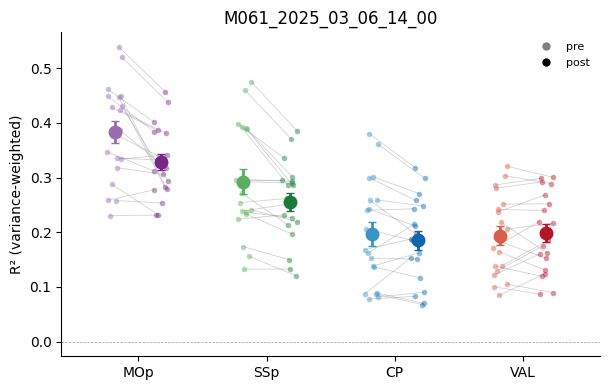

M062_2025_03_21_14_00 | MOp | pre: R²=0.390 ± 0.016
M062_2025_03_21_14_00 | MOp | post: R²=0.283 ± 0.019
M062_2025_03_21_14_00 | SSp | pre: R²=0.338 ± 0.024
M062_2025_03_21_14_00 | SSp | post: R²=0.236 ± 0.022
M062_2025_03_21_14_00 | CP | pre: R²=0.185 ± 0.016
M062_2025_03_21_14_00 | CP | post: R²=0.185 ± 0.012
M062_2025_03_21_14_00 | VAL | pre: R²=0.066 ± 0.013
M062_2025_03_21_14_00 | VAL | post: R²=0.086 ± 0.015


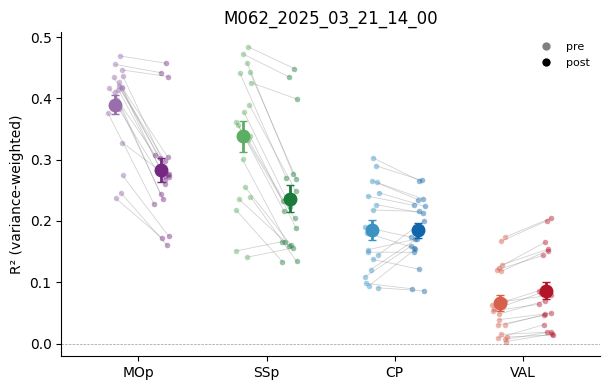

M078_2025_08_06_15_00 | MOp | pre: R²=0.209 ± 0.031
M078_2025_08_06_15_00 | MOp | post: R²=0.189 ± 0.028
M078_2025_08_06_15_00 | SSp | pre: R²=0.145 ± 0.018
M078_2025_08_06_15_00 | SSp | post: R²=0.115 ± 0.013
M078_2025_08_06_15_00 | CP | pre: R²=0.092 ± 0.016
M078_2025_08_06_15_00 | CP | post: R²=0.073 ± 0.012
M078_2025_08_06_15_00 | VAL | pre: R²=0.062 ± 0.015
M078_2025_08_06_15_00 | VAL | post: R²=0.081 ± 0.014


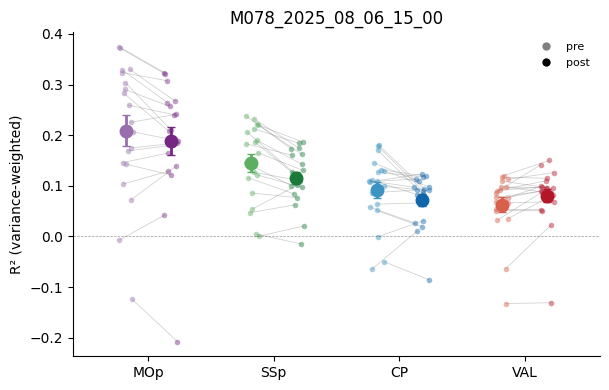

M103_2026_02_18_15_30 | MOp | pre: R²=0.239 ± 0.014
M103_2026_02_18_15_30 | MOp | post: R²=0.215 ± 0.011
M103_2026_02_18_15_30 | SSp | pre: R²=0.257 ± 0.008
M103_2026_02_18_15_30 | SSp | post: R²=0.197 ± 0.012
M103_2026_02_18_15_30 | CP | pre: R²=0.151 ± 0.013
M103_2026_02_18_15_30 | CP | post: R²=0.129 ± 0.007
M103_2026_02_18_15_30 | VAL | pre: R²=0.167 ± 0.016
M103_2026_02_18_15_30 | VAL | post: R²=0.160 ± 0.010


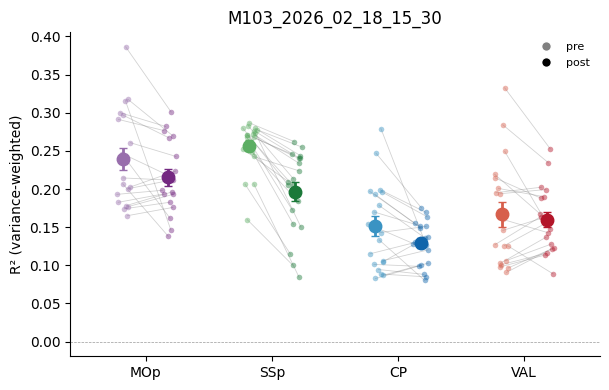

M106_2026_02_25_15_00 | MOp | pre: R²=0.179 ± 0.013
M106_2026_02_25_15_00 | MOp | post: R²=0.193 ± 0.013
M106_2026_02_25_15_00 | SSp | pre: R²=0.208 ± 0.022
M106_2026_02_25_15_00 | SSp | post: R²=0.165 ± 0.017
M106_2026_02_25_15_00 | CP | pre: R²=0.111 ± 0.012
M106_2026_02_25_15_00 | CP | post: R²=0.109 ± 0.011
M106_2026_02_25_15_00 | VAL | pre: R²=0.228 ± 0.018
M106_2026_02_25_15_00 | VAL | post: R²=0.184 ± 0.013


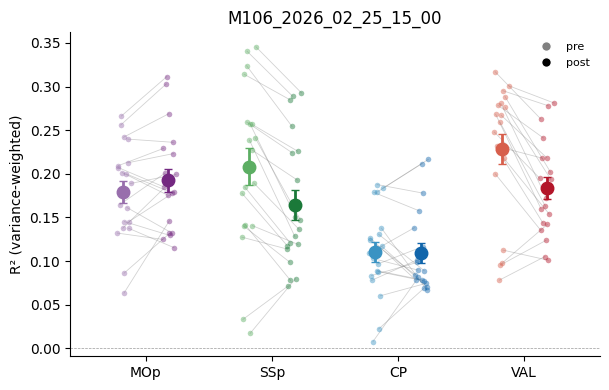

In [17]:
SHOW_SESSIONS = sessions   # edit to subset

OFFSET   = 0.18
JITTER   = 0.06
KP_ALPHA = 0.35
rng      = np.random.default_rng(0)

for sess in SHOW_SESSIONS:
    if sess not in results:
        print(f'Not found: {sess}')
        continue

    sess_areas = [a for a in AREA_ORDER if a in results[sess]]
    if not sess_areas:
        continue

    fig, ax = plt.subplots(figsize=(len(sess_areas) * 1.4 + 0.6, 4))

    for ai, area in enumerate(sess_areas):
        d   = results[sess][area]
        kps = [k for k in d if k != '_meta' and 'pre' in d[k] and 'post' in d[k]]
        if not kps:
            continue

        pre_vals  = np.array([d[kp]['pre'].mean()  for kp in kps])
        post_vals = np.array([d[kp]['post'].mean() for kp in kps])

        col_pre  = AREA_COLORS.get(area, {}).get('pre',  'steelblue')
        col_post = AREA_COLORS.get(area, {}).get('post', 'orange')

        for v_pre, v_post in zip(pre_vals, post_vals):
            jx = rng.uniform(-JITTER, JITTER)
            ax.plot([ai - OFFSET + jx, ai + OFFSET + jx], [v_pre, v_post],
                    color='grey', lw=0.6, alpha=KP_ALPHA, zorder=1)
            ax.scatter(ai - OFFSET + jx, v_pre,  color=col_pre,  s=16,
                       alpha=KP_ALPHA + 0.1, zorder=2, linewidths=0)
            ax.scatter(ai + OFFSET + jx, v_post, color=col_post, s=16,
                       alpha=KP_ALPHA + 0.1, zorder=2, linewidths=0)

        for x, vals, col, win in [
            (ai - OFFSET, pre_vals,  col_pre,  'pre'),
            (ai + OFFSET, post_vals, col_post, 'post'),
        ]:
            m, se = vals.mean(), sem(vals)
            ax.errorbar(x, m, yerr=se, fmt='o', color=col,
                        markersize=9, capsize=3, lw=2, zorder=5)
            print(f'{sess} | {area} | {win}: R²={m:.3f} ± {se:.3f}')

    ax.set_xticks(range(len(sess_areas)))
    ax.set_xticklabels(sess_areas)
    ax.set_ylabel('R² (variance-weighted)')
    ax.set_title(sess)
    ax.set_xlim(-0.6, len(sess_areas) - 0.4)
    ax.axhline(0, color='k', lw=0.5, ls='--', alpha=0.4)
    ax.legend(
        handles=[
            mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
                          markersize=7, label='pre'),
            mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor='k',
                          markersize=7, label='post'),
        ],
        frameon=False, fontsize=8,
    )
    sns.despine(ax=ax)
    fig.tight_layout()
    plt.show()

## 2. Cross-session grand average pre vs post
Each dot is one session (mean across keypoints). Error bar is SEM across sessions.

MOp | pre: R²=0.280 ± 0.045  (n=5 sessions)
MOp | post: R²=0.242 ± 0.028  (n=5 sessions)
SSp | pre: R²=0.248 ± 0.033  (n=5 sessions)
SSp | post: R²=0.194 ± 0.025  (n=5 sessions)
CP | pre: R²=0.147 ± 0.020  (n=5 sessions)
CP | post: R²=0.136 ± 0.022  (n=5 sessions)
VAL | pre: R²=0.144 ± 0.034  (n=5 sessions)
VAL | post: R²=0.142 ± 0.025  (n=5 sessions)


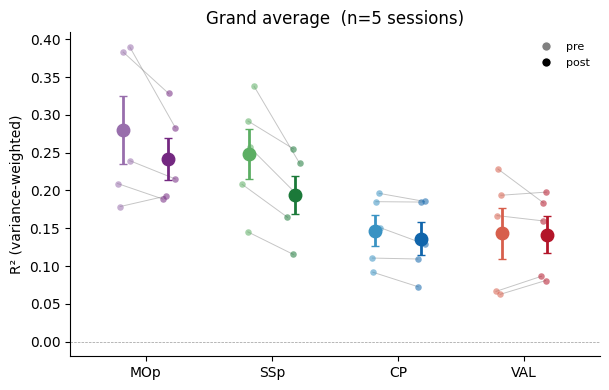

In [22]:
GRAND_SESSIONS = sessions
GRAND_AREAS    = areas
OFFSET         = 0.18
JITTER         = 0.06
KP_ALPHA       = 0.45
rng            = np.random.default_rng(1)

# Per-session mean R² across keypoints for each area × window
sess_vals = {}  # sess → area → window → scalar
for sess in GRAND_SESSIONS:
    if sess not in results:
        continue
    row = {}
    for area in GRAND_AREAS:
        if area not in results[sess]:
            continue
        d   = results[sess][area]
        kps = [k for k in d if k != '_meta' and 'pre' in d[k] and 'post' in d[k]]
        if not kps:
            continue
        row[area] = {
            win: np.mean([d[kp][win].mean() for kp in kps])
            for win in ('pre', 'post')
        }
    if row:
        sess_vals[sess] = row

plot_areas = [a for a in GRAND_AREAS if any(a in v for v in sess_vals.values())]
fig, ax = plt.subplots(figsize=(len(plot_areas) * 1.4 + 0.6, 4))

for ai, area in enumerate(plot_areas):
    col_pre  = AREA_COLORS.get(area, {}).get('pre',  'steelblue')
    col_post = AREA_COLORS.get(area, {}).get('post', 'orange')

    pre_vals  = [sess_vals[s][area]['pre']  for s in sess_vals if area in sess_vals[s]]
    post_vals = [sess_vals[s][area]['post'] for s in sess_vals if area in sess_vals[s]]
    pre_vals, post_vals = np.array(pre_vals), np.array(post_vals)

    for v_pre, v_post in zip(pre_vals, post_vals):
        jx = rng.uniform(-JITTER, JITTER)
        ax.plot([ai - OFFSET + jx, ai + OFFSET + jx], [v_pre, v_post],
                color='grey', lw=0.7, alpha=KP_ALPHA, zorder=1)
        ax.scatter(ai - OFFSET + jx, v_pre,  color=col_pre,  s=22,
                   alpha=KP_ALPHA + 0.1, zorder=2, linewidths=0)
        ax.scatter(ai + OFFSET + jx, v_post, color=col_post, s=22,
                   alpha=KP_ALPHA + 0.1, zorder=2, linewidths=0)

    for x, vals, col, win in [
        (ai - OFFSET, pre_vals,  col_pre,  'pre'),
        (ai + OFFSET, post_vals, col_post, 'post'),
    ]:
        m, se = vals.mean(), sem(vals)
        ax.errorbar(x, m, yerr=se, fmt='o', color=col,
                    markersize=9, capsize=3, lw=2, zorder=5)
        print(f'{area} | {win}: R²={m:.3f} ± {se:.3f}  (n={len(vals)} sessions)')

ax.set_xticks(range(len(plot_areas)))
ax.set_xticklabels(plot_areas)
ax.set_ylabel('R² (variance-weighted)')
ax.set_title(f'Grand average  (n={len(sess_vals)} sessions)')
ax.set_xlim(-0.6, len(plot_areas) - 0.4)
ax.axhline(0, color='k', lw=0.5, ls='--', alpha=0.4)
ax.legend(
    handles=[
        mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
                      markersize=7, label='pre'),
        mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor='k',
                      markersize=7, label='post'),
    ],
    frameon=False, fontsize=8,
)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

## 3. Delta (post − pre) per area
Each dot is one keypoint. Delta = mean(post folds) − mean(pre folds).

NameError: name 'delta' is not defined

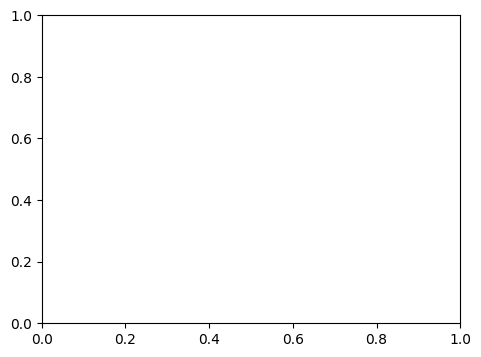

In [23]:
DELTA_SESSIONS = sessions  # edit to subset
DELTA_AREAS    = areas
JITTER         = 0.12
KP_ALPHA       = 0.4
rng            = np.random.default_rng(0)

for sess in DELTA_SESSIONS:
    if sess not in results:
        continue

    sess_areas = [a for a in DELTA_AREAS if a in results[sess]]
    if not sess_areas:
        continue

    fig, ax = plt.subplots(figsize=(len(sess_areas) * 1.2 + 0.6, 4))
    means, xs = [], []

    for ai, area in enumerate(sess_areas):
        d   = results[sess][area]
        kps = [k for k in d if k != '_meta' and 'pre' in d[k] and 'post' in d[k]]
        if not kps:
            continue

        col    = AREA_COLORS.get(area, {}).get('post', 'grey')
        deltas = np.array([delta(d[kp]['pre'], d[kp]['post']) for kp in kps])

        jx = rng.uniform(-JITTER, JITTER, size=len(deltas))
        ax.scatter(ai + jx, deltas, color=col, s=30, alpha=KP_ALPHA, linewidths=0, zorder=2)

        m, se = deltas.mean(), sem(deltas)
        ax.errorbar(ai, m, yerr=se, fmt='o', color=col,
                    markersize=10, capsize=3, lw=2, zorder=4)
        means.append(m)
        xs.append(ai)
        print(f'{sess} | {area}: delta={m:+.3f} ± {se:.3f}  (n={len(deltas)} kps)')

    ax.plot(xs, means, color='grey', lw=1.2, zorder=3)
    ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
    ax.set_xticks(range(len(sess_areas)))
    ax.set_xticklabels(sess_areas)
    ax.set_ylabel('ΔR² (post − pre)')
    ax.set_title(sess)
    ax.set_xlim(-0.6, len(sess_areas) - 0.4)
    sns.despine(ax=ax)
    fig.tight_layout()
    plt.show()


## 4. Heatmap: paired delta per keypoint × area (averaged across sessions)

In [21]:
HM_SESSIONS = sessions
HM_AREAS    = areas

all_kps = sorted({
    kp
    for sess in HM_SESSIONS if sess in results
    for area in HM_AREAS if area in results[sess]
    for kp in results[sess][area] if kp != '_meta'
})

# Sort keypoints by mean delta across all areas and sessions
kp_global_delta = []
for kp in all_kps:
    vals = []
    for sess in HM_SESSIONS:
        if sess not in results:
            continue
        for area in HM_AREAS:
            if area not in results[sess] or kp not in results[sess][area]:
                continue
            d = results[sess][area][kp]
            vals.append(delta(d['pre'], d['post']))
    kp_global_delta.append(np.mean(vals) if vals else np.nan)

sort_idx  = np.argsort(kp_global_delta)[::-1]
kp_sorted = [all_kps[i] for i in sort_idx]

# One subplot per area: keypoints × sessions
sess_labels = [s[5:10] for s in HM_SESSIONS]
n_areas = len(HM_AREAS)
fig, axes = plt.subplots(1, n_areas,
                         figsize=(n_areas * (len(HM_SESSIONS) * 0.55 + 0.8),
                                  len(all_kps) * 0.38 + 1.2),
                         sharey=True)
if n_areas == 1:
    axes = [axes]

# Shared colour scale across all areas
all_deltas = []
for area in HM_AREAS:
    for sess in HM_SESSIONS:
        if sess not in results or area not in results[sess]:
            continue
        d = results[sess][area]
        for kp in all_kps:
            if kp in d:
                all_deltas.append(delta(d[kp]['pre'], d[kp]['post']))
vlim = np.max(np.abs(all_deltas)) if all_deltas else 1.0

for ax, area in zip(axes, HM_AREAS):
    mat = np.full((len(kp_sorted), len(HM_SESSIONS)), np.nan)
    for si, sess in enumerate(HM_SESSIONS):
        if sess not in results or area not in results[sess]:
            continue
        d = results[sess][area]
        for ki, kp in enumerate(kp_sorted):
            if kp in d:
                mat[ki, si] = delta(d[kp]['pre'], d[kp]['post'])

    im = ax.imshow(mat, aspect='auto', cmap='RdBu_r',
                   vmin=-vlim, vmax=vlim, interpolation='nearest')
    ax.set_xticks(range(len(HM_SESSIONS)))
    ax.set_xticklabels(sess_labels, rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(len(kp_sorted)))
    ax.set_yticklabels(kp_sorted, fontsize=8)
    ax.set_title(area, fontweight='bold')

    print(f'\n{area}')
    for si, sess in enumerate(HM_SESSIONS):
        col = mat[:, si]
        valid = col[~np.isnan(col)]
        if len(valid):
            print(f'  {sess}: delta={valid.mean():+.3f} ± {sem(valid):.3f}  (n={len(valid)} kps)')

plt.colorbar(im, ax=axes[-1], label='ΔR² (post − pre)', shrink=0.6)
fig.suptitle('Delta per keypoint × session', fontweight='bold')
fig.tight_layout()
plt.show()


NameError: name 'delta' is not defined

## 5. Cross-session delta: each dot is one session

In [ ]:
CROSS_SESSIONS = sessions
CROSS_AREAS    = areas
JITTER         = 0.08
rng            = np.random.default_rng(2)

# Per-session mean delta across keypoints
sess_deltas = {}  # sess → area → scalar
for sess in CROSS_SESSIONS:
    if sess not in results:
        continue
    row = {}
    for area in CROSS_AREAS:
        if area not in results[sess]:
            continue
        d   = results[sess][area]
        kps = [k for k in d if k != '_meta' and 'pre' in d[k] and 'post' in d[k]]
        if not kps:
            continue
        row[area] = np.mean([delta(d[kp]['pre'], d[kp]['post']) for kp in kps])
    if row:
        sess_deltas[sess] = row

plot_areas = [a for a in CROSS_AREAS if any(a in v for v in sess_deltas.values())]
fig, ax = plt.subplots(figsize=(len(plot_areas) * 1.4 + 0.6, 4))
means, xs = [], []

for ai, area in enumerate(plot_areas):
    col    = AREA_COLORS.get(area, {}).get('post', 'grey')
    deltas = np.array([sess_deltas[s][area] for s in sess_deltas if area in sess_deltas[s]])

    jx = rng.uniform(-JITTER, JITTER, size=len(deltas))
    ax.scatter(ai + jx, deltas, color=col, s=40, alpha=0.6, linewidths=0, zorder=2)

    m, se = deltas.mean(), sem(deltas)
    ax.errorbar(ai, m, yerr=se, fmt='o', color=col,
                markersize=10, capsize=3, lw=2, zorder=4)
    means.append(m)
    xs.append(ai)
    print(f'{area}: delta={m:+.3f} ± {se:.3f}  (n={len(deltas)} sessions)')

ax.plot(xs, means, color='grey', lw=1.2, zorder=3)
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
ax.set_xticks(range(len(plot_areas)))
ax.set_xticklabels(plot_areas)
ax.set_ylabel('ΔR² (post − pre)')
ax.set_title(f'Cross-session delta  (n={len(sess_deltas)} sessions)')
ax.set_xlim(-0.6, len(plot_areas) - 0.4)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()
